In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
plt.style.use("dstyle")
_ = plt.figure()
plt.style.use("dstyle")

<Figure size 3000x2400 with 0 Axes>

In [3]:
MPC_CGS     = 3.0857e24
KM_CGS      = 1.e5
GYRS_CGS    = 3.1536e16

H0_DESI = 67.97
H0_Pantheon = 68.03
H0_Union3 = 66.53
H0_DESY5 = 67.24

H0_cgs_DESICMB = H0_DESI * (KM_CGS / MPC_CGS)
H0_cgs_Pantheon = H0_Pantheon * (KM_CGS / MPC_CGS)
H0_cgs_Union3 = H0_Union3 * (KM_CGS / MPC_CGS)
H0_cgs_DESY5 = H0_DESY5 * (KM_CGS / MPC_CGS)

In [4]:
table_fname_DESICMB = "Lambda_study/integration_tables/table_DESI.txt"
table_fname_Pantheon = "Lambda_study/integration_tables/table_Pantheon.txt"
table_fname_Union3 = "Lambda_study/integration_tables/table_Union3.txt"
table_fname_DESY5 = "Lambda_study/integration_tables/table_DESY5.txt"

nskiprows = 10

table_DESICMB = np.loadtxt(table_fname_DESICMB, skiprows=nskiprows, delimiter = ',')
table_Pantheon = np.loadtxt(table_fname_Pantheon, skiprows=nskiprows, delimiter = ',')
table_Union3 = np.loadtxt(table_fname_Union3, skiprows=nskiprows, delimiter = ',')
table_DESY5 = np.loadtxt(table_fname_DESY5, skiprows=nskiprows, delimiter = ',')

In [5]:
z_arr = table_DESICMB[:,0]
l_z_arr = table_DESICMB[:,1]
a_arr = table_DESICMB[:,2]

time_look_DESICMB = table_DESICMB[:,3]
time_age_DESICMB = table_DESICMB[:,4]
time_ageGyr_DESICMB = time_age_DESICMB / H0_cgs_DESICMB / GYRS_CGS

time_look_Pantheon = table_Pantheon[:,3]
time_age_Pantheon = table_Pantheon[:,4]
time_ageGyr_Pantheon = time_age_Pantheon / H0_cgs_Pantheon / GYRS_CGS

time_look_Union3 = table_Union3[:,3]
time_age_Union3 = table_Union3[:,4]
time_ageGyr_Union3 = time_age_Union3 / H0_cgs_Union3 / GYRS_CGS

time_look_DESY5 = table_DESY5[:,3]
time_age_DESY5 = table_DESY5[:,4]
time_ageGyr_DESY5 = time_age_DESY5 / H0_cgs_DESY5 / GYRS_CGS

In [6]:
strlabel_DESICMB = r"$\rm{DESI+CMB}$"
strlabel_Pantheon = r"$\rm{DESI+CMB}+\Lambda\rm{Pantheon}$"
strlabel_DESY5 = r"$\rm{DESI+CMB}+\Lambda\rm{DESY5}$"
strlabel_Union3 = r"$\rm{DESI+CMB}+\Lambda\rm{Union3}$"

In [7]:
def a2z(a):
    return (1. / a) - 1.

def z2a(z):
    return 1. / (1. + z)



In [8]:
redshifts_lookref = np.array([0.5, 1.0, 2.0])
a_lookref = 1. / (1. + redshifts_lookref)
a_lookref_0, a_lookref_1, a_lookref_2 = a_lookref
strlabel_lookref_0 = rf"$z = {redshifts_lookref[0]:.2f}$"
strlabel_lookref_1 = rf"$z = {redshifts_lookref[1]:.2f}$"
strlabel_lookref_2 = rf"$z = {redshifts_lookref[2]:.2f}$"

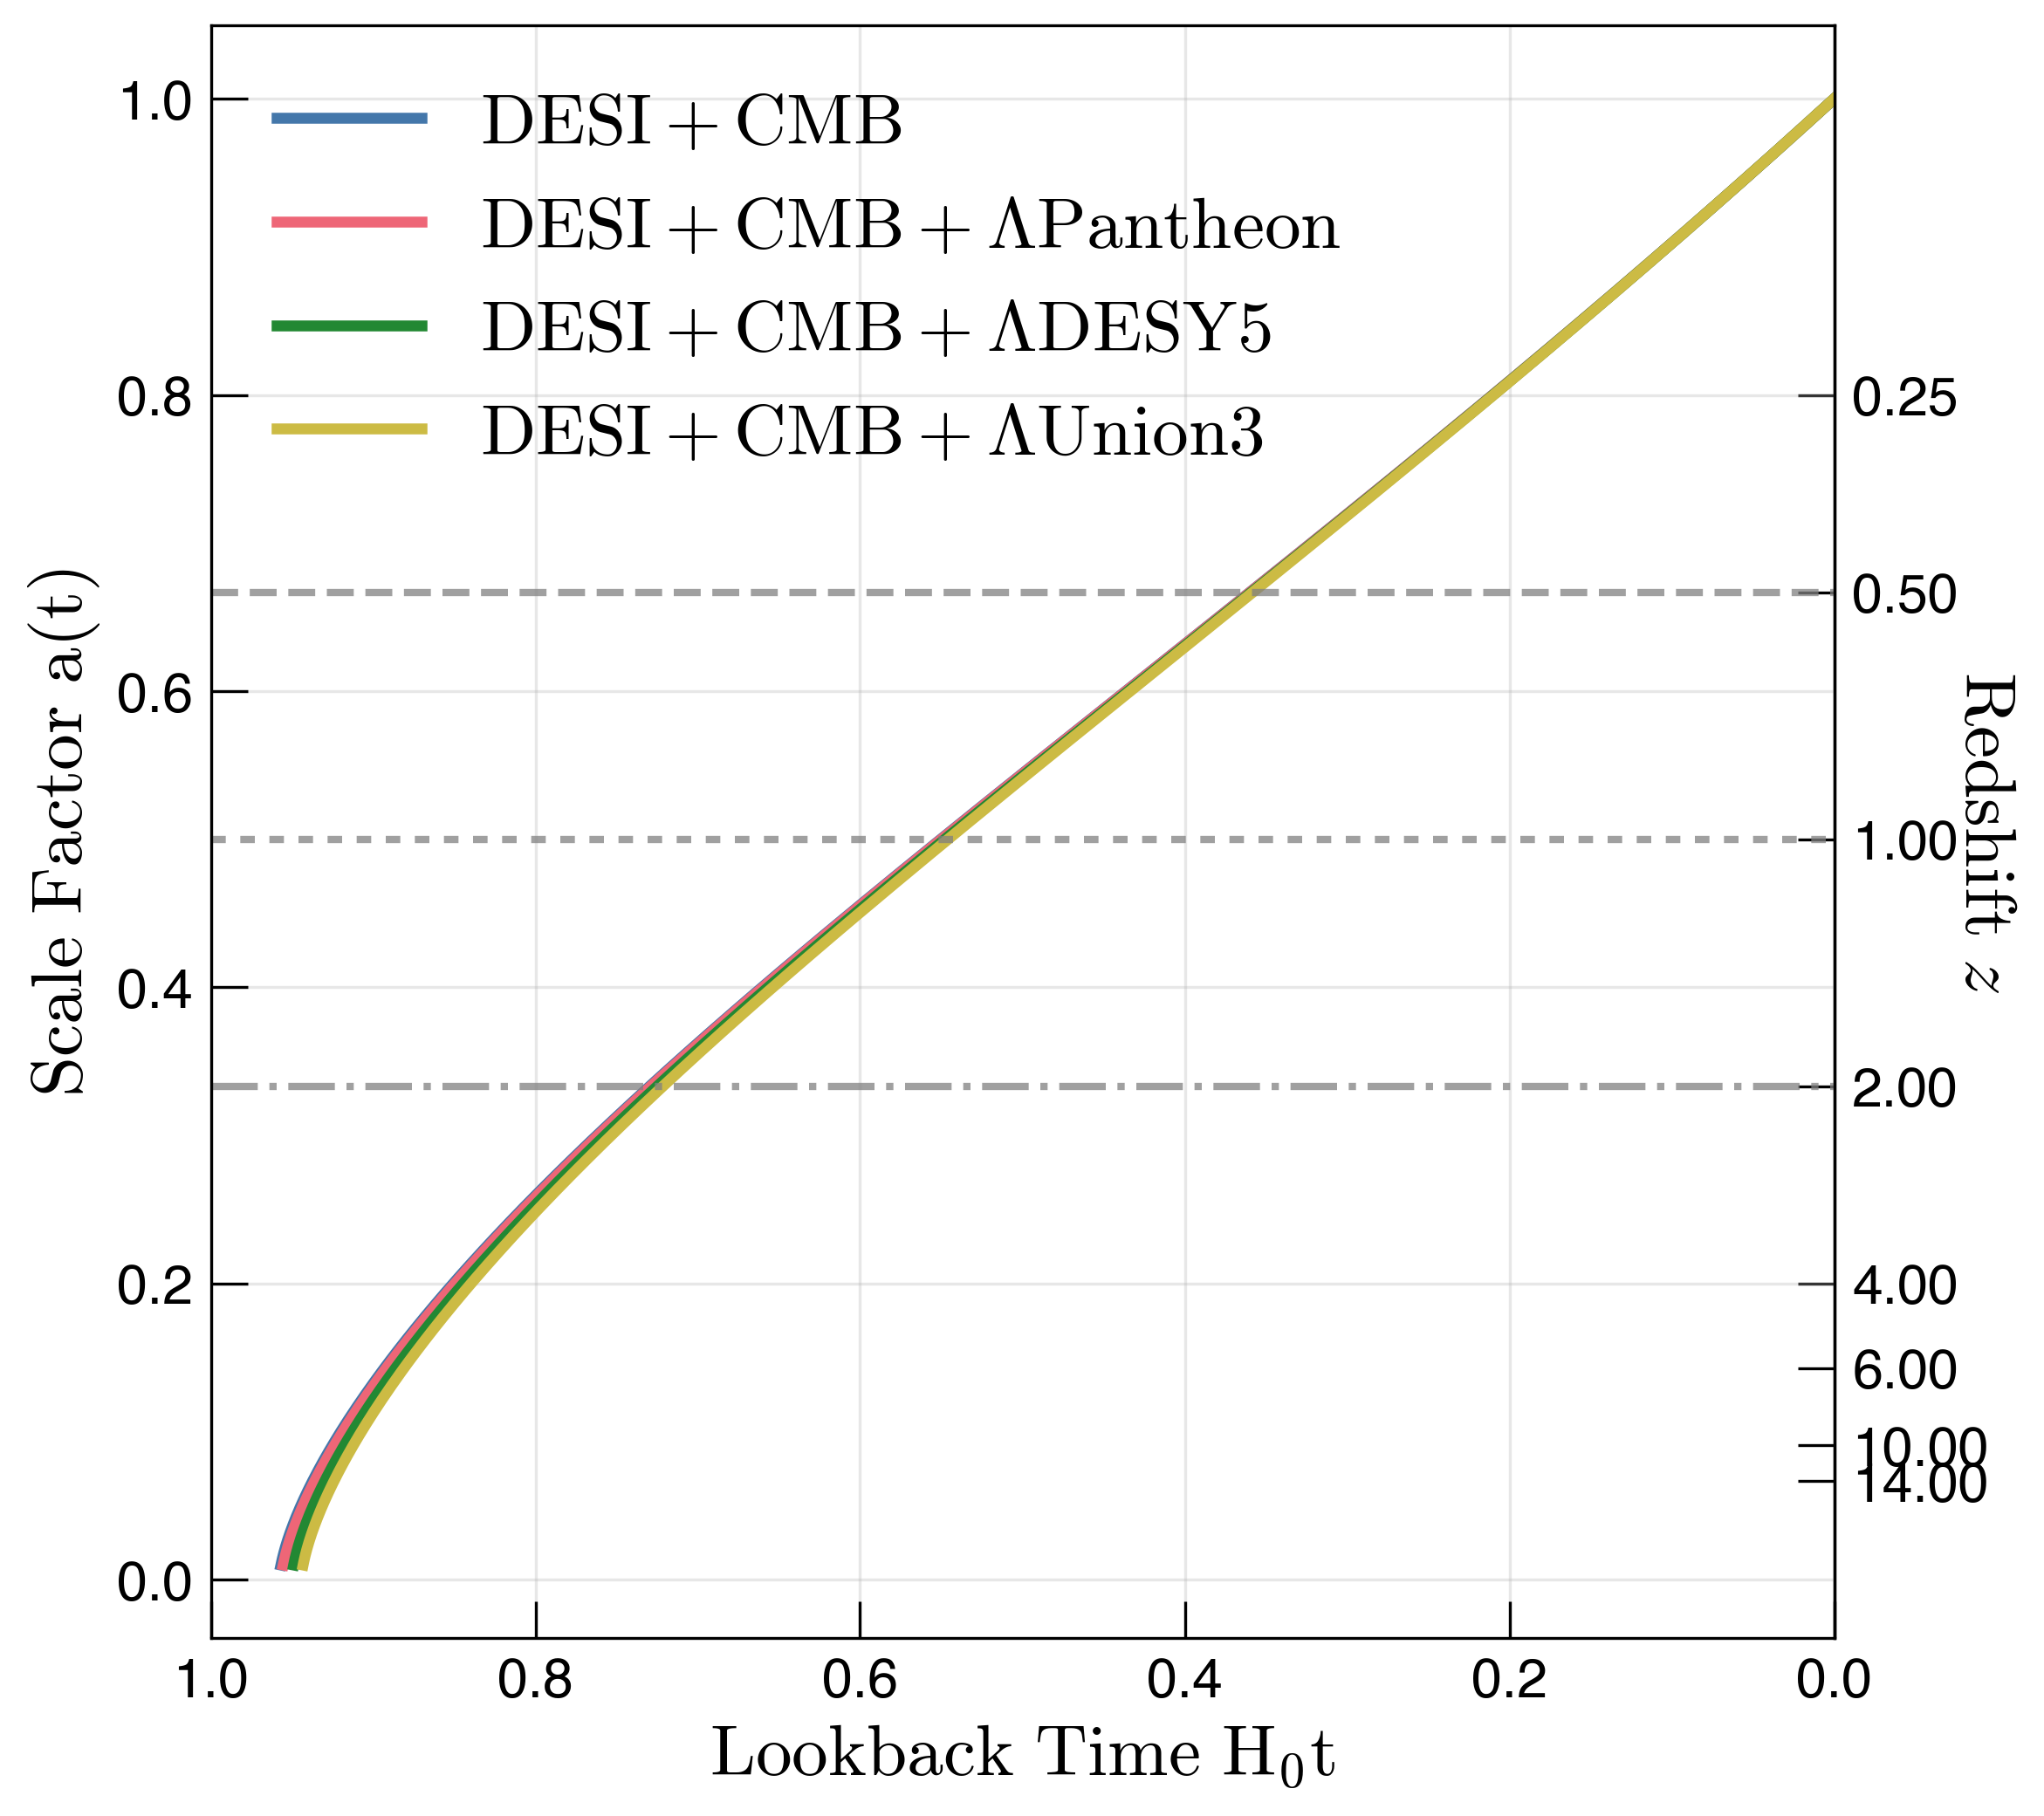

In [9]:
fig, ax = plt.subplots(figsize=(8,8), nrows=1, ncols=1)

_ = ax.plot(time_look_DESICMB, a_arr, label=strlabel_DESICMB, lw=3)
_ = ax.plot(time_look_Pantheon, a_arr, label=strlabel_Pantheon, lw=3)
_ = ax.plot(time_look_DESY5, a_arr, label=strlabel_DESY5, lw=3)
_ = ax.plot(time_look_Union3, a_arr, label=strlabel_Union3, lw=3)

_ = ax.axhline(a_lookref_0, c='gray', ls='--', lw=2, alpha=0.75)
_ = ax.axhline(a_lookref_1, c='gray', ls=':', lw=2, alpha=0.75)
_ = ax.axhline(a_lookref_2, c='gray', ls='-.', lw=2, alpha=0.75)

_ = ax.set_xlabel(r"$\rm{Lookback}\  \rm{Time}\ H_0 t$", fontsize=20)
_ = ax.set_ylabel(r"$\rm{Scale}\ \rm{Factor}\ a(t) $", fontsize=20)

_ = ax.set_xlim(1.0,0.)

ax2y = ax.secondary_yaxis('right', functions=(a2z, z2a))
_ = ax2y.set_yticks([0.25, 0.5, 1., 2., 4., 6., 10., 14])
_ = ax2y.set_ylabel(r"$\rm{Redshift}$" + r"$\ z$", rotation=270, labelpad=8, fontsize=20)

_ = ax.grid(alpha=0.3)

_ = plt.legend(loc='upper left')

In [10]:
agefn_DESICMB = interpolate.interp1d(z_arr, time_ageGyr_DESICMB)
agefn_Union3 = interpolate.interp1d(z_arr, time_ageGyr_Union3)
agefn_Pantheon = interpolate.interp1d(z_arr, time_ageGyr_Pantheon)
agefn_DESY5 = interpolate.interp1d(z_arr, time_ageGyr_DESY5)

scalefn_DESICMB = interpolate.interp1d(time_look_DESICMB, a_arr)

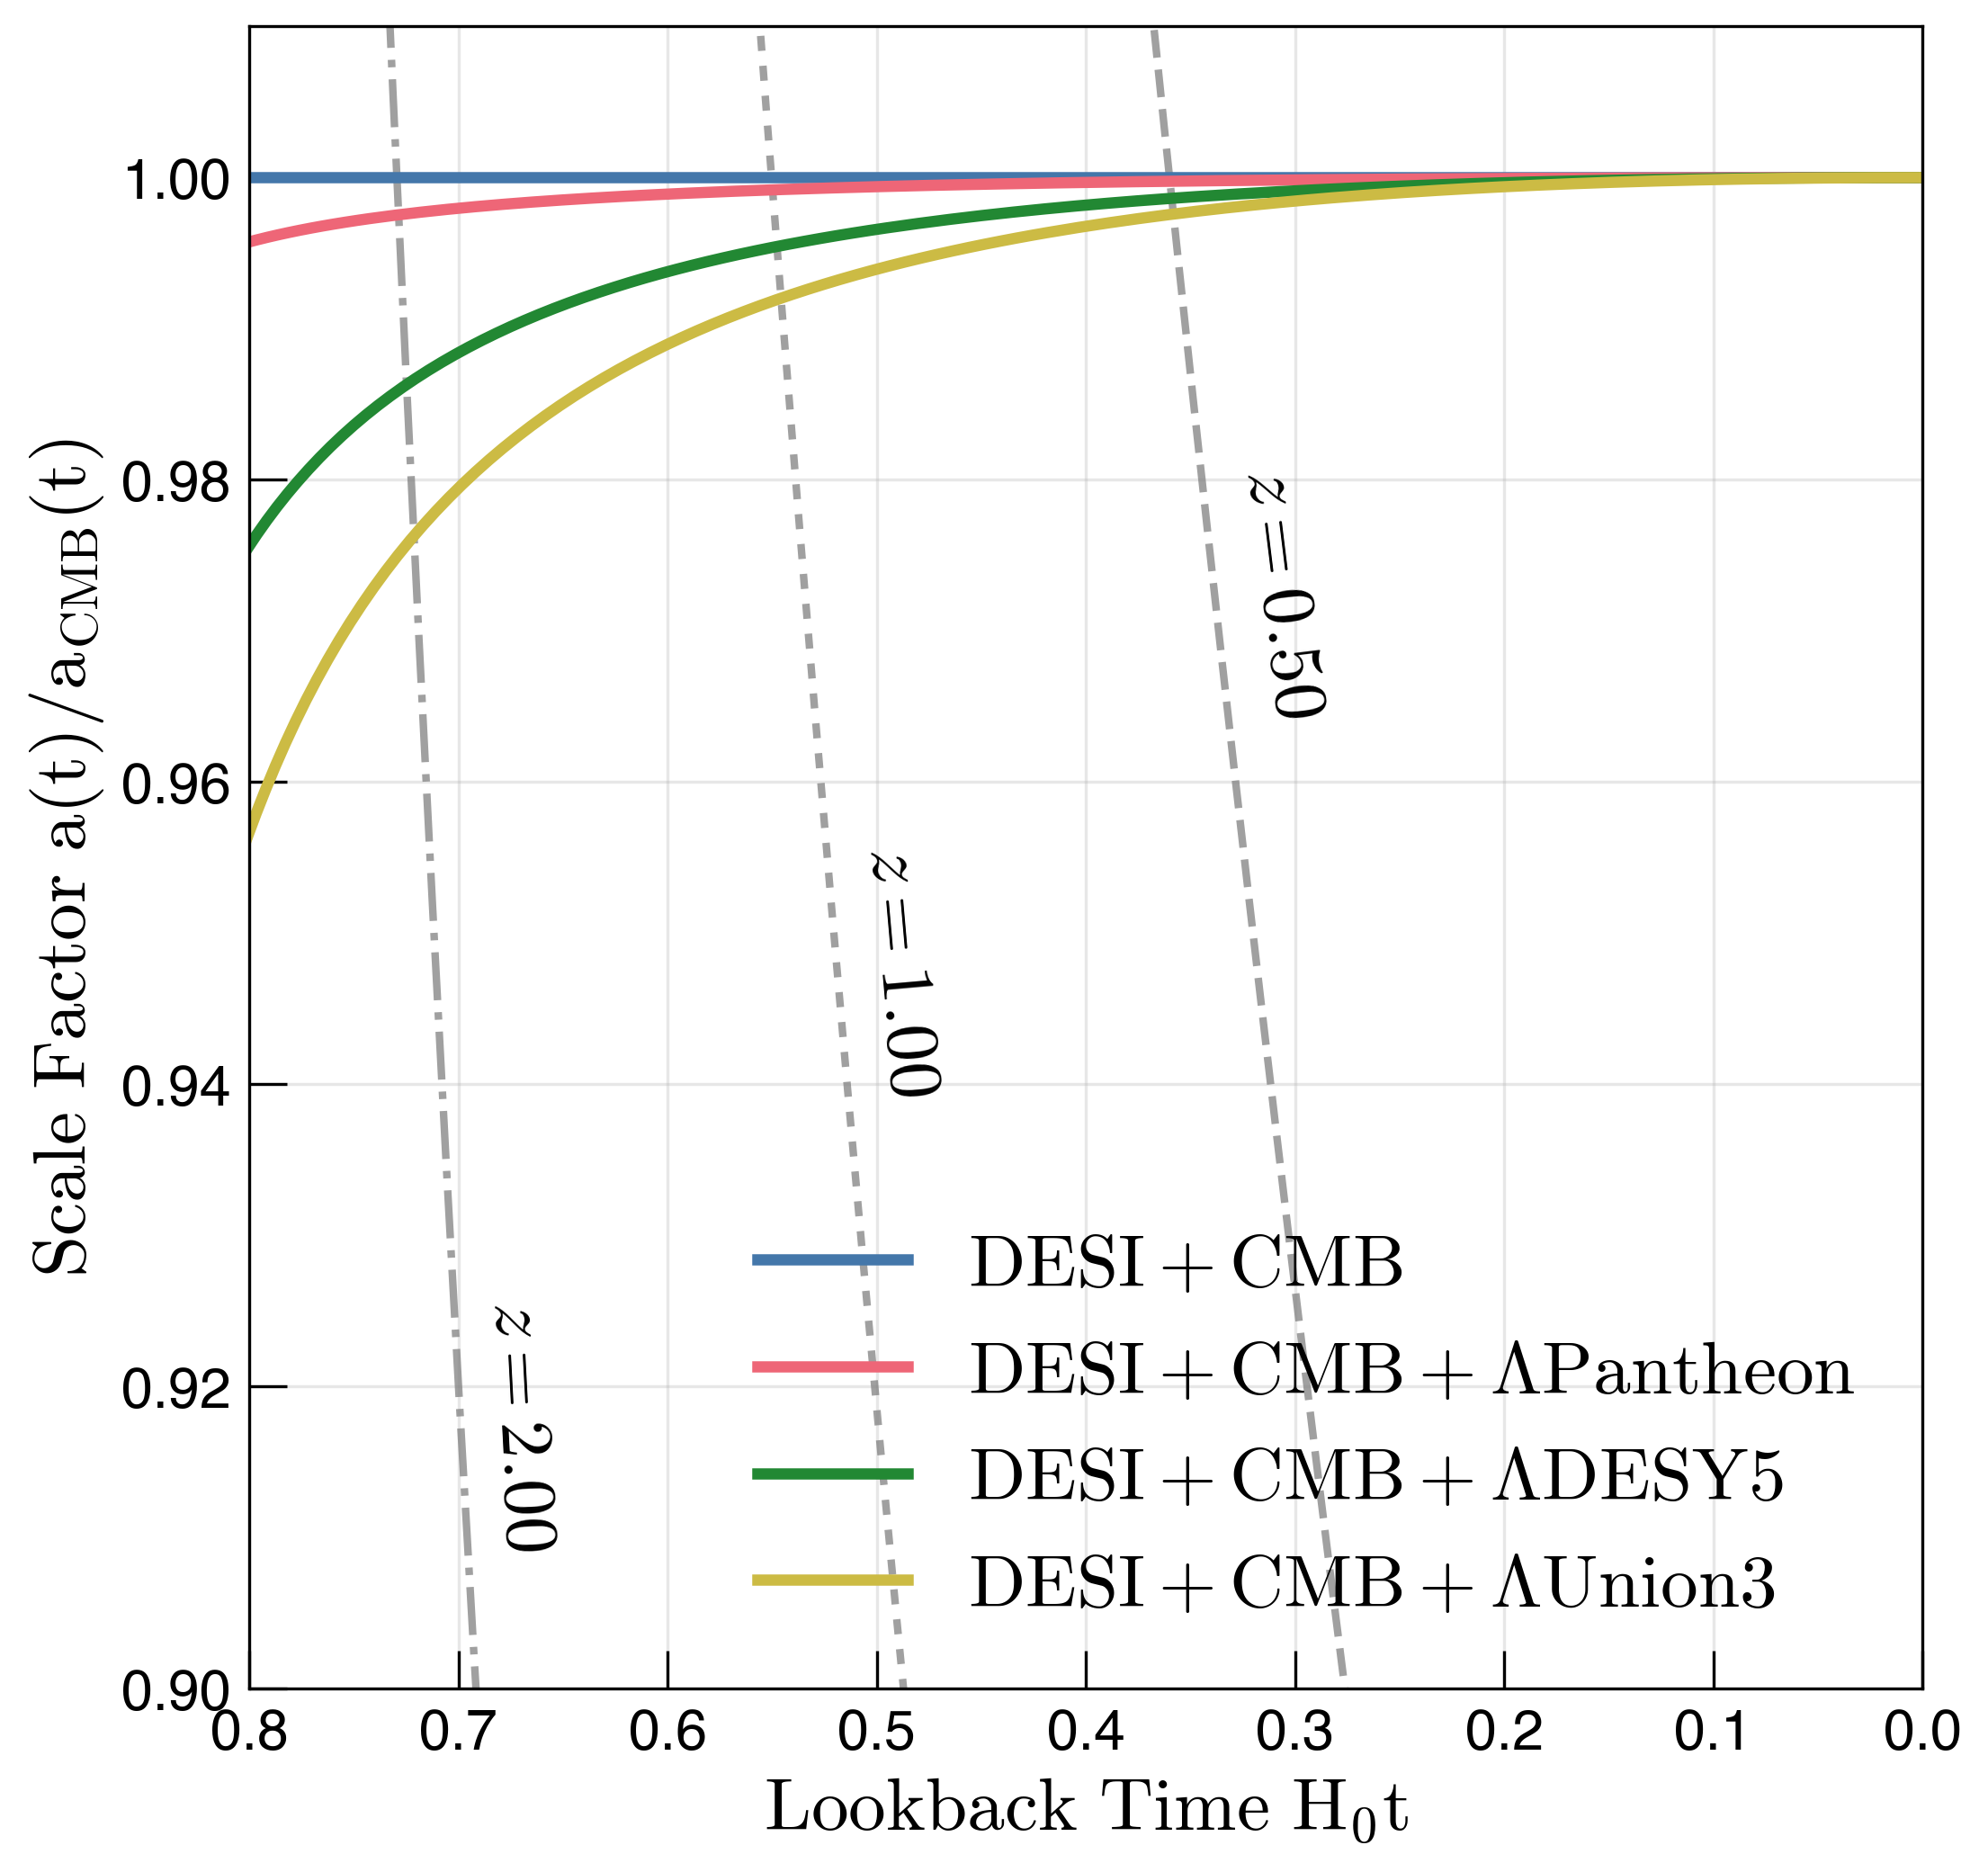

In [11]:
fig, ax = plt.subplots(figsize=(8,8), nrows=1, ncols=1)

aDESICMB_Concordance = scalefn_DESICMB(time_look_DESICMB[1:])
aPantheon_Concordance = scalefn_DESICMB(time_look_Pantheon[1:])
aDESY5_Concordance = scalefn_DESICMB(time_look_DESY5[1:])
aUnion3_Concordance = scalefn_DESICMB(time_look_Union3[1:])


_ = ax.plot(time_look_DESICMB, a_lookref_0 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls='--', lw=2, alpha=0.75)
_ = ax.plot(time_look_DESICMB, a_lookref_1 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls=':', lw=2, alpha=0.75)
_ = ax.plot(time_look_DESICMB, a_lookref_2 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls='-.', lw=2, alpha=0.75)

_ = ax.plot(time_look_DESICMB[1:], a_arr[1:]/aDESICMB_Concordance, label=strlabel_DESICMB, lw=3)
_ = ax.plot(time_look_Pantheon[1:], a_arr[1:]/aPantheon_Concordance, label=strlabel_Pantheon, lw=3)
_ = ax.plot(time_look_DESY5[1:], a_arr[1:]/aDESY5_Concordance, label=strlabel_DESY5, lw=3)
_ = ax.plot(time_look_Union3[1:], a_arr[1:]/aUnion3_Concordance, label=strlabel_Union3, lw=3)


x_redshift = 0.33
y_redshift = 0.965
_ = ax.annotate(strlabel_lookref_0, xy=(x_redshift, y_redshift), fontsize=20, rotation=277)

x_redshift = 0.51
y_redshift = 0.94
_ = ax.annotate(strlabel_lookref_1, xy=(x_redshift, y_redshift), fontsize=20, rotation=275)

x_redshift = 0.69
y_redshift = 0.91
_ = ax.annotate(strlabel_lookref_2, xy=(x_redshift, y_redshift), fontsize=20, rotation=273)

_ = ax.set_xlabel(r"Lookback time ($H_0 t$)")
_ = ax.set_ylabel("scale factor ($a / a_{\Lambda}$)")

_ = ax.set_xlabel(r"$\rm{Lookback}\  \rm{Time}\ H_0 t$", fontsize=20)
_ = ax.set_ylabel(r"$\rm{Scale}\ \rm{Factor}\ a(t) / a_{\rm{CMB}}(t) $", fontsize=20)

_ = ax.set_xlim(0.8,0.)
_ = ax.set_ylim(0.90, 1.01)

_ = ax.grid(alpha=0.3)


legend_obj = plt.legend(loc='lower right', alignment='right')


_ = plt.savefig('Diff_Expansion_ZoomIn_Lambda.png', bbox_inches='tight', dpi=256)

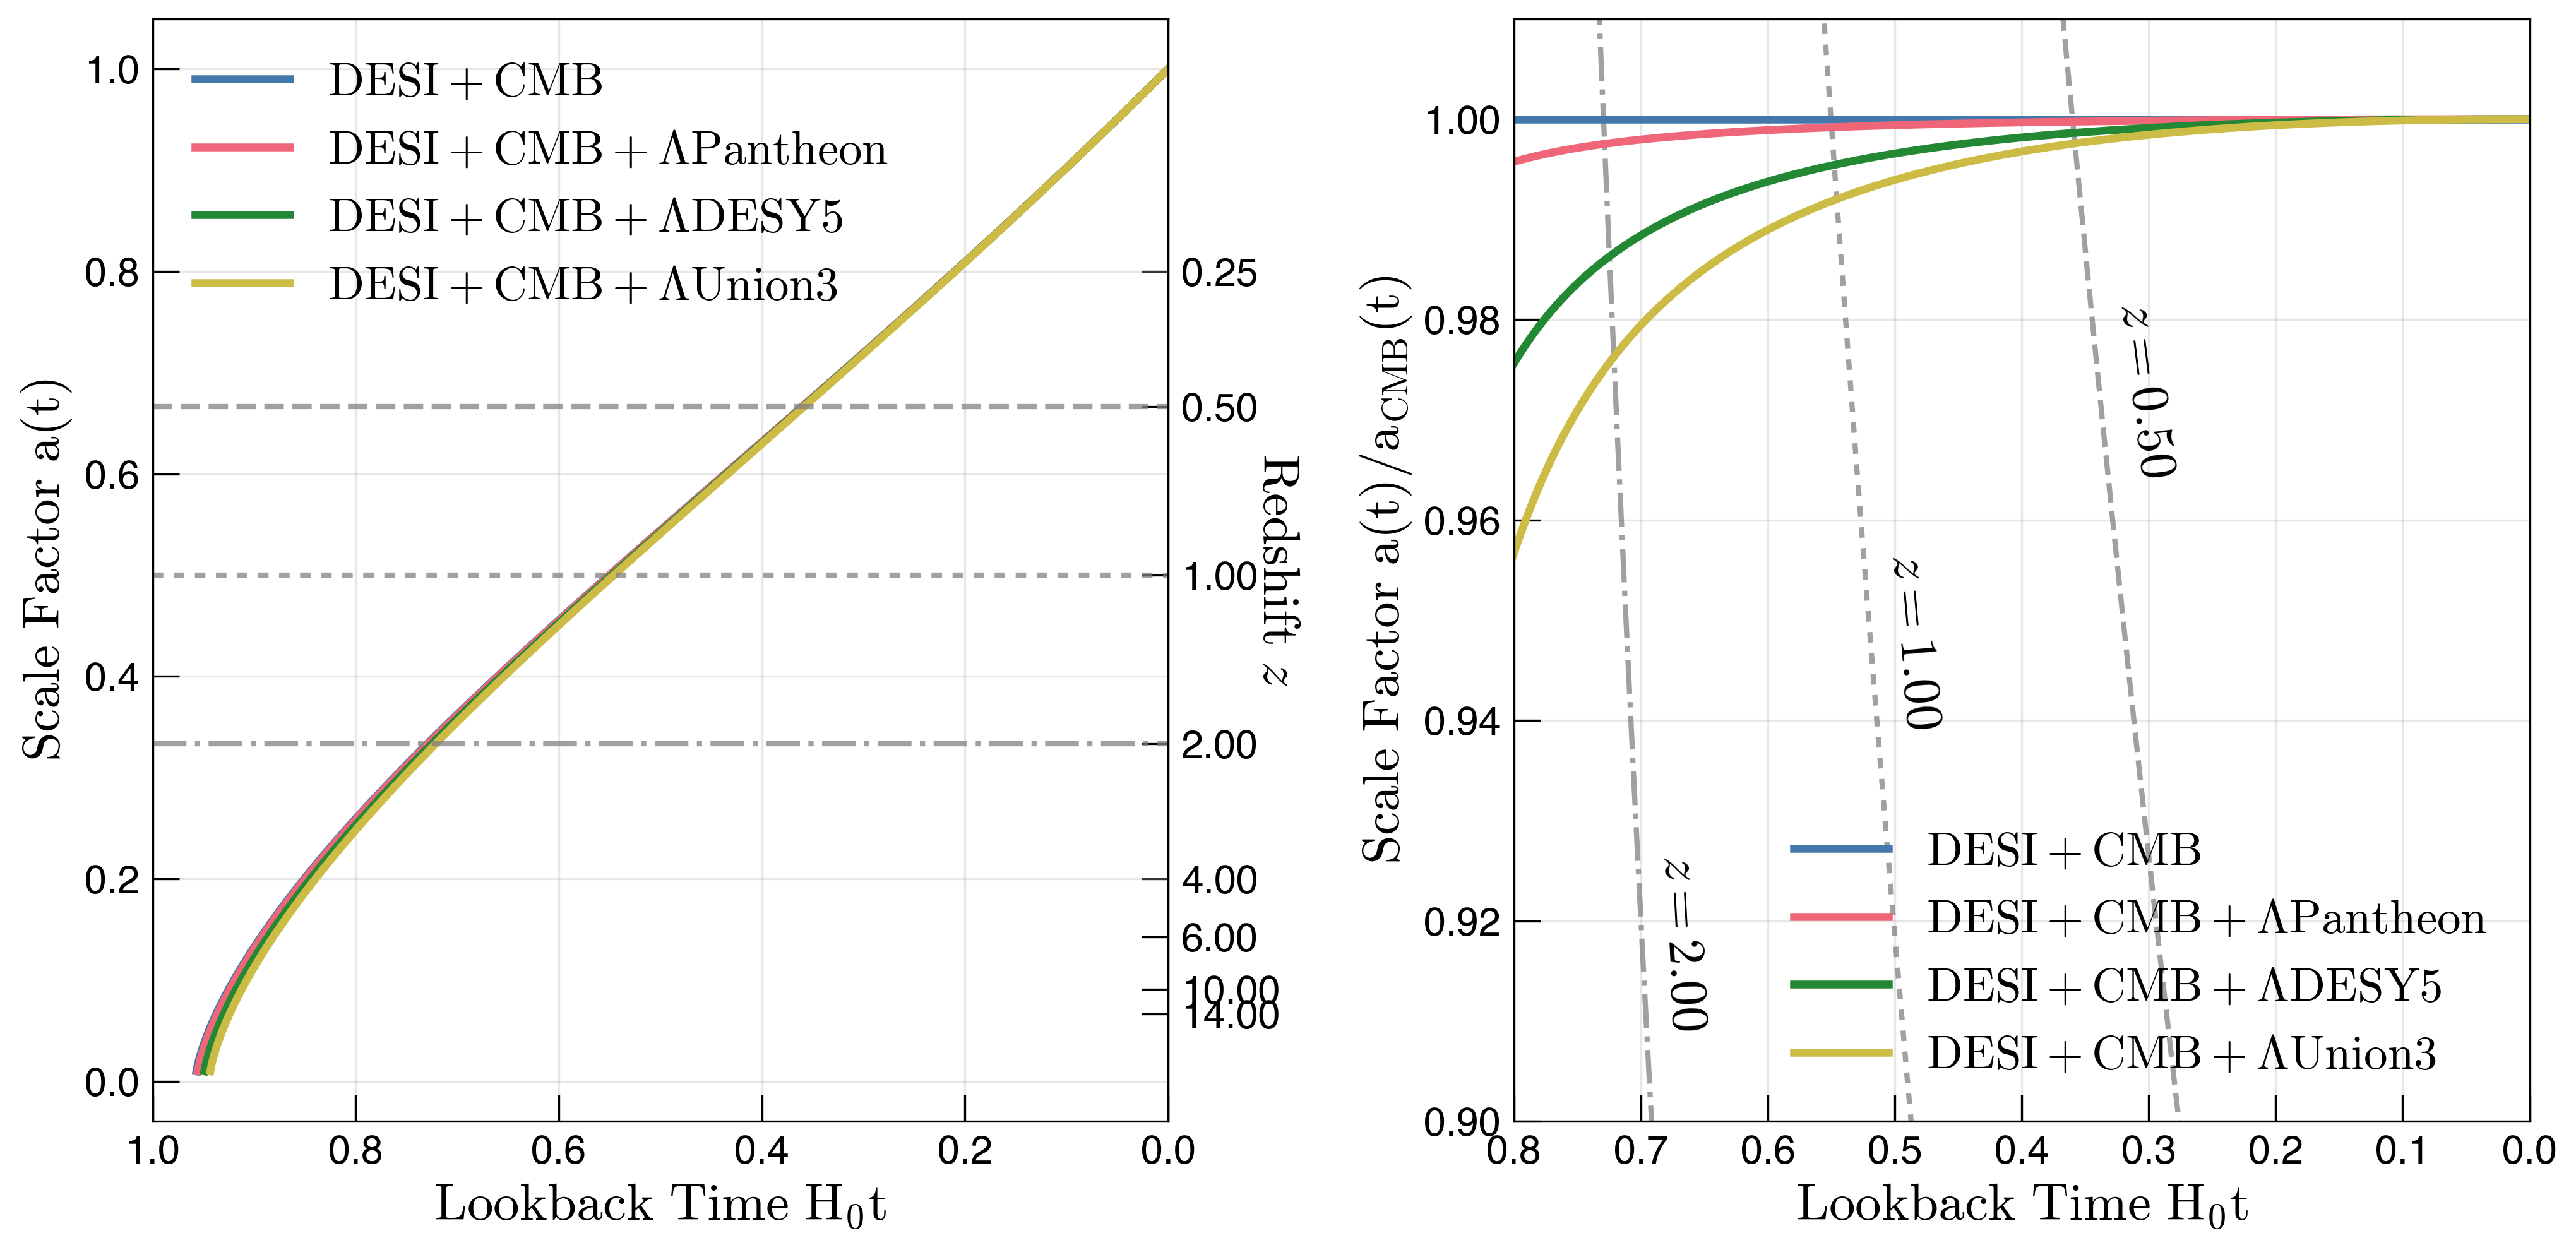

In [12]:
fig, ax_all = plt.subplots(figsize=(14,7), nrows=1, ncols=2)
ax_look, ax_lookdiff = ax_all



_ = ax_look.plot(time_look_DESICMB, a_arr, label=strlabel_DESICMB, lw=3)
_ = ax_look.plot(time_look_Pantheon, a_arr, label=strlabel_Pantheon, lw=3)
_ = ax_look.plot(time_look_DESY5, a_arr, label=strlabel_DESY5, lw=3)
_ = ax_look.plot(time_look_Union3, a_arr, label=strlabel_Union3, lw=3)


_ = ax_look.axhline(a_lookref_0, c='gray', ls='--', lw=2, alpha=0.75)
_ = ax_look.axhline(a_lookref_1, c='gray', ls=':', lw=2, alpha=0.75)
_ = ax_look.axhline(a_lookref_2, c='gray', ls='-.', lw=2, alpha=0.75)

_ = ax_look.set_xlabel(r"$\rm{Lookback}\  \rm{Time}\ H_0 t$", fontsize=20)
_ = ax_look.set_ylabel(r"$\rm{Scale}\ \rm{Factor}\ a(t) $", fontsize=20)

_ = ax_look.set_xlim(1.0,0.)

ax2y = ax_look.secondary_yaxis('right', functions=(a2z, z2a))
_ = ax2y.set_yticks([0.25, 0.5, 1., 2., 4., 6., 10., 14])
_ = ax2y.set_ylabel(r"$\rm{Redshift}$" + r"$\ z$", rotation=270, labelpad=8, fontsize=20)

_ = ax_look.grid(alpha=0.3)




_ = ax_lookdiff.plot(time_look_DESICMB, a_lookref_0 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls='--', lw=2, alpha=0.75)
_ = ax_lookdiff.plot(time_look_DESICMB, a_lookref_1 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls=':', lw=2, alpha=0.75)
_ = ax_lookdiff.plot(time_look_DESICMB, a_lookref_2 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls='-.', lw=2, alpha=0.75)

x_redshift = 0.33
y_redshift = 0.965
_ = ax_lookdiff.annotate(strlabel_lookref_0, xy=(x_redshift, y_redshift), fontsize=20, rotation=277)

x_redshift = 0.51
y_redshift = 0.94
_ = ax_lookdiff.annotate(strlabel_lookref_1, xy=(x_redshift, y_redshift), fontsize=20, rotation=275)

x_redshift = 0.69
y_redshift = 0.91
_ = ax_lookdiff.annotate(strlabel_lookref_2, xy=(x_redshift, y_redshift), fontsize=20, rotation=273)


_ = ax_lookdiff.plot(time_look_DESICMB[1:], a_arr[1:]/aDESICMB_Concordance, label=strlabel_DESICMB, lw=3)
_ = ax_lookdiff.plot(time_look_Pantheon[1:], a_arr[1:]/aPantheon_Concordance, label=strlabel_Pantheon, lw=3)
_ = ax_lookdiff.plot(time_look_DESY5[1:], a_arr[1:]/aDESY5_Concordance, label=strlabel_DESY5, lw=3)
_ = ax_lookdiff.plot(time_look_Union3[1:], a_arr[1:]/aUnion3_Concordance, label=strlabel_Union3, lw=3)


_ = ax_lookdiff.set_xlabel(r"Lookback time ($H_0 t$)")
_ = ax_lookdiff.set_ylabel("scale factor ($a / a_{\Lambda}$)")

_ = ax_lookdiff.set_xlabel(r"$\rm{Lookback}\  \rm{Time}\ H_0 t$", fontsize=20)
_ = ax_lookdiff.set_ylabel(r"$\rm{Scale}\ \rm{Factor}\ a(t) / a_{\rm{CMB}}(t) $", fontsize=20)

_ = ax_lookdiff.set_xlim(0.8,0.)
_ = ax_lookdiff.set_ylim(0.90, 1.01)


for ax in ax_all:
    _ = ax.grid(alpha=0.3)

_ = ax_look.legend(loc='upper left', fontsize=18)
_ = ax_lookdiff.legend(loc='lower right', alignment='right', fontsize=18)

_ = fig.tight_layout()


_ = plt.savefig('Expansion_ZoomIn_Lambda.png', bbox_inches='tight', dpi=256)